In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt
import os

plt.style.use('seaborn-v0_8-whitegrid')

os.makedirs("project5-optimization_charts", exist_ok=True)


end_date = dt.date.today()
start_date = end_date - dt.timedelta(days = 5*365)

stocks = ["AAPL", "KO", "^GSPC", "NVDA", "GC=F", "MSFT"]

df = yf.download(stocks, start= start_date, end = end_date)['Close']

df

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,GC=F,KO,MSFT,NVDA,^GSPC
Date,,,,,,
2021-08-30,149.348816,1809.000000,48.455711,291.363525,22.609793,4528.790039
2021-08-31,148.090607,1815.000000,48.567833,289.722473,22.311773,4522.680176
2021-09-01,148.753845,1813.099976,48.895584,289.674408,22.367592,4524.089844
2021-09-02,149.865768,1808.699951,48.964581,289.021881,22.322739,4536.950195
2021-09-03,150.499756,1830.900024,48.930088,289.012299,22.768280,4535.430176
...,...,...,...,...,...,...
2026-08-24,310.339996,4640.799805,91.989998,487.309998,208.479996,7652.859863
2026-08-25,309.899994,4638.100098,91.639999,491.709991,213.050003,7677.279785
2026-08-26,313.450012,4598.200195,90.080002,496.369995,209.660004,7675.700195


In [2]:
returns = df.pct_change().dropna()
returns

C:\Users\yashr\AppData\Local\Temp\ipykernel_20328\119691768.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change().dropna()


Ticker,AAPL,GC=F,KO,MSFT,NVDA,^GSPC
Date,,,,,,
2021-08-31,-0.008425,0.003317,0.002314,-0.005632,-0.013181,-0.001349
2021-09-01,0.004479,-0.001047,0.006748,-0.000166,0.002502,0.000312
2021-09-02,0.007475,-0.002427,0.001411,-0.002253,-0.002005,0.002843
2021-09-03,0.004230,0.012274,-0.000704,-0.000033,0.019959,-0.000335
2021-09-07,0.015490,-0.019116,-0.018685,-0.003188,-0.007924,-0.003396
...,...,...,...,...,...,...
2026-08-24,0.003200,0.003611,0.009769,0.008422,-0.029061,-0.002803
2026-08-25,-0.001418,-0.000582,-0.003805,0.009029,0.021921,0.003191
2026-08-26,0.011455,-0.008603,-0.017023,0.009477,-0.015912,-0.000206


In [3]:
covariance = returns.cov()*252
covariance

Ticker,AAPL,GC=F,KO,MSFT,NVDA,^GSPC
Ticker,,,,,,
AAPL,0.078383,0.001153,0.011785,0.041788,0.069167,0.034430
GC=F,0.001153,0.035210,0.000811,0.001773,0.004309,0.003132
KO,0.011785,0.000811,0.027806,0.006231,-0.002164,0.007567
MSFT,0.041788,0.001773,0.006231,0.079062,0.082451,0.033236
NVDA,0.069167,0.004309,-0.002164,0.082451,0.269572,0.062858
^GSPC,0.034430,0.003132,0.007567,0.033236,0.062858,0.028963


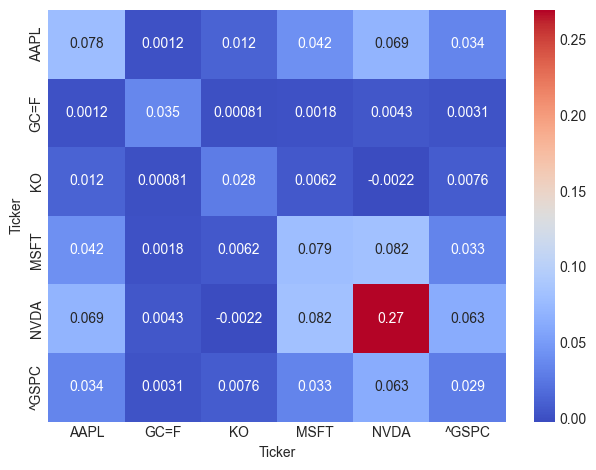

In [4]:
sns.heatmap(covariance, cmap = 'coolwarm', annot = True)

plt.tight_layout()
plt.savefig("project5-optimization_charts/covariance_heatmap.png", dpi=300, bbox_inches="tight")

In [5]:
annualreturns = returns.mean()*252

In [6]:
def simulate(maxweight, num_simulations = 10000):
    num_assets = len(stocks)
    allweights = np.random.default_rng().dirichlet(np.ones(num_assets), size=num_simulations)

    returns_list = []
    volatility_list = []
    sharpe_list = []

    accepted_weights = []

    for weight in allweights:
        if np.any(weight > maxweight):
            continue
        portfolioreturn = (annualreturns*weight).sum()
        returns_list.append(portfolioreturn)

        portfoliovariance = weight.T @ covariance @ weight

        portfoliovolatility = np.sqrt(portfoliovariance)
        volatility_list.append(portfoliovolatility)
        
        sharpe = portfolioreturn/portfoliovolatility
        sharpe_list.append(sharpe)

        accepted_weights.append(weight)
    
    data = {
    'Returns': returns_list,
    'Volatility': volatility_list,
    'Sharpe': sharpe_list
}

    frontier = pd.DataFrame(data)
    return frontier, accepted_weights
    

In [7]:
frontier, accepted_weights = simulate(1.0)
frontier.shape

(10000, 3)

In [8]:
max_sharpe_idx = frontier['Sharpe'].idxmax()
min_vol_idx = frontier['Volatility'].idxmin()

In [9]:
msr_portfolio = frontier.loc[max_sharpe_idx]
mvp_portfolio = frontier.loc[min_vol_idx]

In [10]:
best_weights = accepted_weights[max_sharpe_idx]

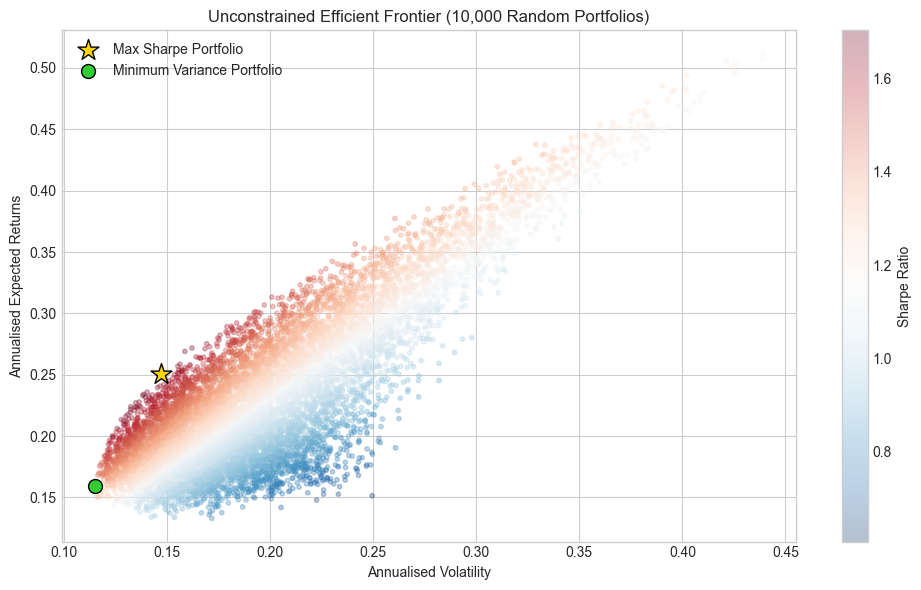

In [11]:
plt.figure(figsize=(10, 6))

# Plot all 10,000 random portfolios
scatter = plt.scatter(
    frontier['Volatility'], 
    frontier['Returns'], 
    c=frontier['Sharpe'], 
    #cmap='RdYlBu_r', 
    cmap = 'RdBu_r',
    s=10, 
    alpha=0.3
)

plt.scatter(
    msr_portfolio['Volatility'],
    msr_portfolio['Returns'],
    color='gold',
    marker='*',
    s=250,
    edgecolor='black',
    label='Max Sharpe Portfolio'
)

# Minimum Variance Portfolio
plt.scatter(
    mvp_portfolio['Volatility'],
    mvp_portfolio['Returns'],
    color='limegreen',
    marker='o',
    s=100,
    edgecolor='black',
    label='Minimum Variance Portfolio'
)

plt.legend()

# Add a color bar on the side to show what the colors mean
plt.colorbar(scatter, label='Sharpe Ratio')
plt.xlabel('Annualised Volatility')
plt.ylabel('Annualised Expected Returns')
plt.title("Unconstrained Efficient Frontier (10,000 Random Portfolios)")

plt.tight_layout()
plt.savefig("project5-optimization_charts/efficient_frontier.png", dpi=300, bbox_inches="tight")


In [12]:
frontier.loc[frontier['Sharpe'].idxmax()]

Returns       0.250376
Volatility    0.146958
Sharpe        1.703722
Name: 1980, dtype: float64

In [13]:
frontier.loc[frontier['Volatility'].idxmin()]

Returns       0.159053
Volatility    0.114921
Sharpe        1.384016
Name: 4714, dtype: float64

In [14]:
newfrontier, newaccepted_weights = simulate(0.3)
newfrontier.shape

(1438, 3)

In [15]:
newmax_sharpe_idx = newfrontier['Sharpe'].idxmax()
newmin_vol_idx = newfrontier['Volatility'].idxmin()

newmsr_portfolio = newfrontier.loc[newmax_sharpe_idx]
newmvp_portfolio = newfrontier.loc[newmin_vol_idx]

newbest_weights = newaccepted_weights[newmax_sharpe_idx]

Accepted Portfolios: 1,438
Acceptance Rate: 14.4%


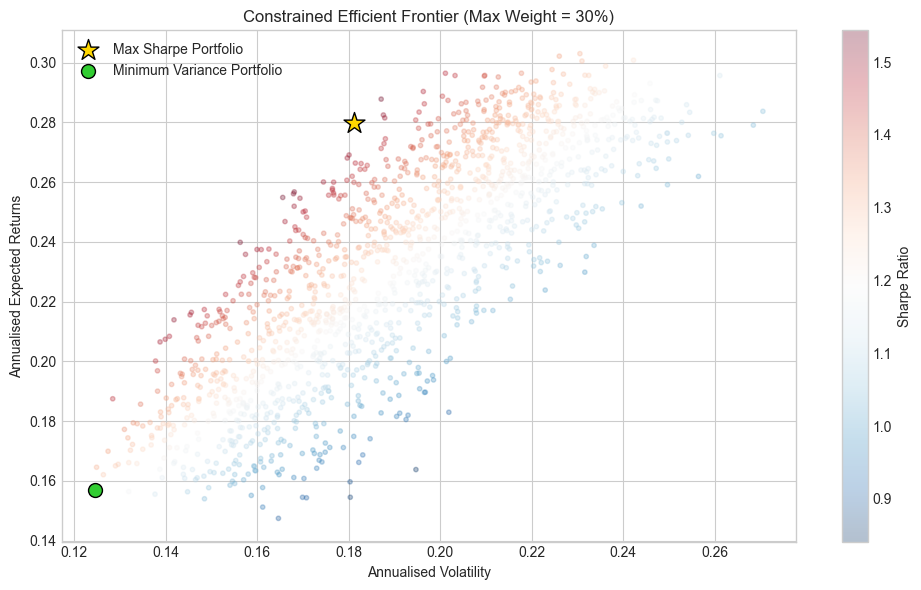

In [16]:
plt.figure(figsize=(10, 6))

# Plot all 10,000 random portfolios
scatter = plt.scatter(
    newfrontier['Volatility'], 
    newfrontier['Returns'], 
    c=newfrontier['Sharpe'], 
    #cmap='RdYlBu_r', 
    cmap = 'RdBu_r',
    s=10, 
    alpha=0.3
)

plt.scatter(
    newmsr_portfolio['Volatility'],
    newmsr_portfolio['Returns'],
    color='gold',
    marker='*',
    s=250,
    edgecolor='black',
    label='Max Sharpe Portfolio'
)

# Minimum Variance Portfolio
plt.scatter(
    newmvp_portfolio['Volatility'],
    newmvp_portfolio['Returns'],
    color='limegreen',
    marker='o',
    s=100,
    edgecolor='black',
    label='Minimum Variance Portfolio'
)

plt.legend()


# Add a color bar on the side to show what the colors mean
plt.colorbar(scatter, label='Sharpe Ratio')
plt.xlabel('Annualised Volatility')
plt.ylabel('Annualised Expected Returns')

plt.title("Constrained Efficient Frontier (Max Weight = 30%)")

print(f"Accepted Portfolios: {len(newaccepted_weights):,}")
print(f"Acceptance Rate: {len(newaccepted_weights)/10000:.1%}")

plt.tight_layout()
plt.savefig("project5-optimization_charts/constrained_frontier.png", dpi=300, bbox_inches="tight")

In [17]:
newfrontier.loc[newfrontier['Sharpe'].idxmax()]
newfrontier.loc[newfrontier['Volatility'].idxmin()]

Returns       0.156902
Volatility    0.124484
Sharpe        1.260421
Name: 1078, dtype: float64

In [18]:
comparison_summary = pd.DataFrame({
    "Unconstrained": msr_portfolio,
    "Constrained": newmsr_portfolio
}).round(3)

comparison_summary

,Unconstrained,Constrained
Returns,0.250,0.280
Volatility,0.147,0.181
Sharpe,1.704,1.544


In [19]:
optimal_weights = pd.DataFrame({
    "Asset": stocks,
    "Unconstrained": best_weights,
    "Constrained": newbest_weights
})

optimal_weights

,Asset,Unconstrained,Constrained
0,AAPL,0.033753,0.055143
1,KO,0.456709,0.286271
2,^GSPC,0.285259,0.279557
3,NVDA,0.040950,0.058026
4,GC=F,0.174366,0.262286
5,MSFT,0.008962,0.058717


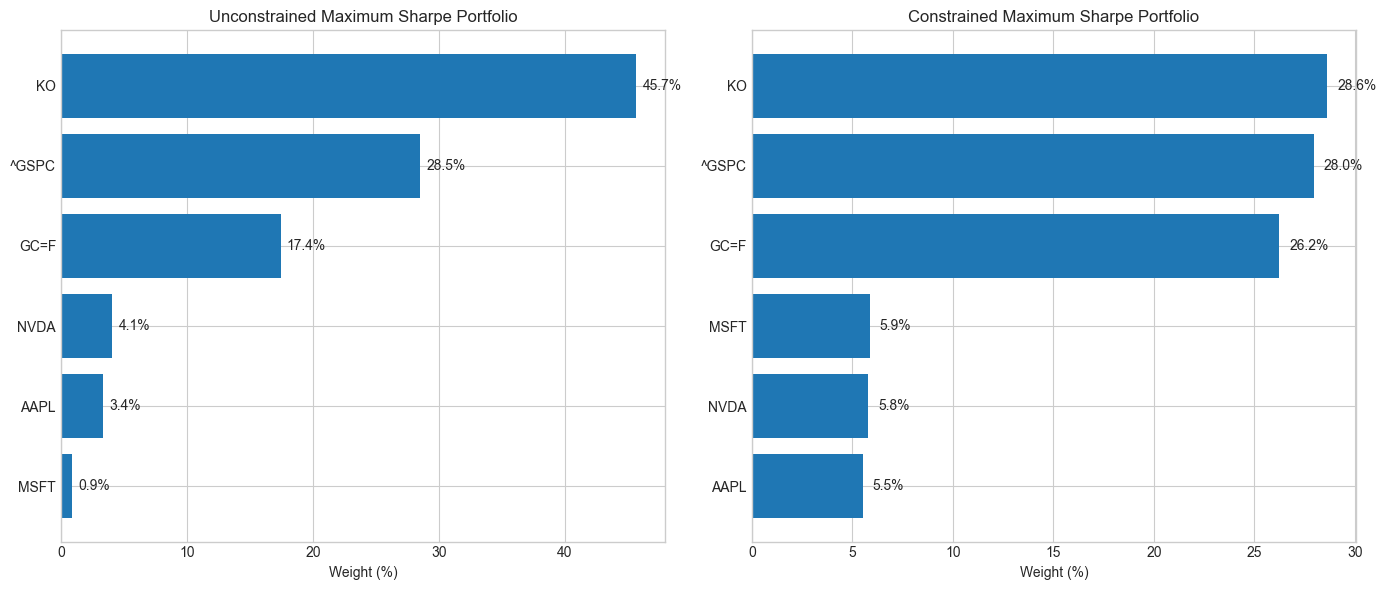

In [20]:
weights_df = pd.DataFrame({
    "Asset": stocks,
    "Weight": best_weights * 100
})

weights_df = weights_df.sort_values("Weight", ascending=True)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,6))

ax1.barh(weights_df["Asset"], weights_df["Weight"])
ax1.set_xlabel("Weight (%)")
ax1.set_title("Unconstrained Maximum Sharpe Portfolio")

for i, value in enumerate(weights_df["Weight"]):
    ax1.text(value + 0.5, i, f"{value:.1f}%", va="center")

constrainedweights_df = pd.DataFrame({
    "Asset": stocks,
    "Weight": newbest_weights * 100
})

constrainedweights_df = constrainedweights_df.sort_values("Weight", ascending=True)

ax2.barh(constrainedweights_df["Asset"], constrainedweights_df["Weight"])
ax2.set_xlabel("Weight (%)")
ax2.set_title("Constrained Maximum Sharpe Portfolio")

for i, value in enumerate(constrainedweights_df["Weight"]):
    ax2.text(value + 0.5, i, f"{value:.1f}%", va="center")


plt.tight_layout()
plt.savefig("project5-optimization_charts/max_sharpe_weights.png", dpi=300, bbox_inches="tight")

In [21]:
comparison = pd.DataFrame({
    "Metric": ["Return", "Volatility", "Sharpe"],
    "Unconstrained": [
        msr_portfolio["Returns"],
        msr_portfolio["Volatility"],
        msr_portfolio["Sharpe"]
    ],
    "Constrained": [
        newmsr_portfolio["Returns"],
        newmsr_portfolio["Volatility"],
        newmsr_portfolio["Sharpe"]
    ]
})

comparison = comparison.round(3)

comparison

,Metric,Unconstrained,Constrained
0,Return,0.250,0.280
1,Volatility,0.147,0.181
2,Sharpe,1.704,1.544


In [29]:
optimal_weights[["Asset", "Constrained"]].to_csv(
    "optimized_weights.csv",
    index=False
)

,Asset,Unconstrained,Constrained
0,AAPLAAPLAAPLAAPLAAPLAAPLAAPLAAPLAAPLAAPLAAPLAA...,3.375315,5.514344
1,KOKOKOKOKOKOKOKOKOKOKOKOKOKOKOKOKOKOKOKOKOKOKO...,45.670857,28.627119
2,^GSPC^GSPC^GSPC^GSPC^GSPC^GSPC^GSPC^GSPC^GSPC^...,28.525946,27.955669
3,NVDANVDANVDANVDANVDANVDANVDANVDANVDANVDANVDANV...,4.095046,5.802551
4,GC=FGC=FGC=FGC=FGC=FGC=FGC=FGC=FGC=FGC=FGC=FGC...,17.436601,26.228574
5,MSFTMSFTMSFTMSFTMSFTMSFTMSFTMSFTMSFTMSFTMSFTMS...,0.896236,5.871743
